In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import sys, os
import torch
print(torch.__version__)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.dates as mdates
import plotly.express as px

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
print(module_path)

# from light_transformer_analysis import *
from explainability_analysis.transformer_analysis import *
from explainability_analysis.crop_spectral_signature_analysis import *
from explainability_analysis.visualization_functions import *
from explainability_analysis.visualization_constants import *

figure_results_path = "/home/luca/luca_docker/results/crop-type-classification-explainability/plots/attn_weights_patterns"
base_model_path = "/home/luca/luca_docker/results/crop-type-classification-explainability/paper"

dataset = "DENETHOR"




2.0.0+cu117
/home/luca/luca_docker/crop-type-classification-explainability


Initializing DENETHORS2Dataset trainvalid partition in s2-utm-33N-18E-242N
read 9 classes
precached dataset files found at /home/luca/luca_docker/datasets/DENETHOR/npy/s2-utm-33N-18E-242N/trainvalid
Dataset /home/luca/luca_docker/datasets/DENETHOR. region s2-utm-33N-18E-242N. partition trainvalid.X:2504x(55, 15), y:2504 with 9 classes
Initializing DENETHORS2Dataset test partition in s2-utm-33N-17E-243N
read 9 classes
precached dataset files found at /home/luca/luca_docker/datasets/DENETHOR/npy/s2-utm-33N-17E-243N/test
Dataset /home/luca/luca_docker/datasets/DENETHOR. region s2-utm-33N-17E-243N. partition test.X:2043x(62, 15), y:2043 with 9 classes
Max sequence length is 82
Calculating spectral indices for dataset: s2-utm-33N-18E-242N_trainvalid
Calculating spectral indices for dataset: s2-utm-33N-17E-243N_test


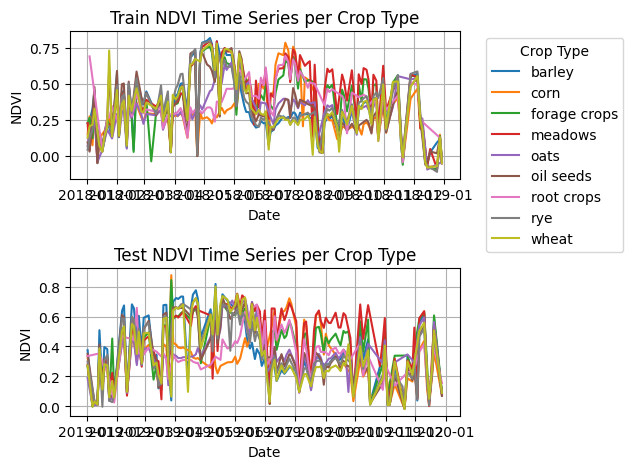

In [37]:
# Load NDVI - ground truth
train_spectral_indices, test_spectral_indices = get_dataset_spectral_indices(dataset=dataset, partition='test')
train_avg_ndvi_time_series = train_spectral_indices.groupby(['Crop type', 'Date'])['NDVI'].mean().reset_index()
test_avg_ndvi_time_series = test_spectral_indices.groupby(['Crop type', 'Date'])['NDVI'].mean().reset_index()
# cropsvar_ndvi_time_series = avg_ndvi_time_series.groupby('Date')['NDVI'].var().sort_index()

# two subplots: train & test:
fig, axs = plt.subplots(2, 1)
# Plot train NDVI time series per crop type
sns.lineplot(data=train_avg_ndvi_time_series, x='Date', y='NDVI', hue='Crop type', ax=axs[0])
axs[0].set_title('Train NDVI Time Series per Crop Type')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('NDVI')
axs[0].xaxis.set_major_locator(mdates.MonthLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axs[0].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0].grid(True)   
# Plot test NDVI time series per crop type
sns.lineplot(data=test_avg_ndvi_time_series, x='Date', y='NDVI', hue='Crop type', ax=axs[1], legend=False)
axs[1].set_title('Test NDVI Time Series per Crop Type')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('NDVI')
axs[1].xaxis.set_major_locator(mdates.MonthLocator())
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# axs[1].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].grid(True)
plt.tight_layout()
plt.show()


In [ ]:
test_spectral_indices


/tmp/ipykernel_3337283/1212157664.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipykernel_3337283/1212157664.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


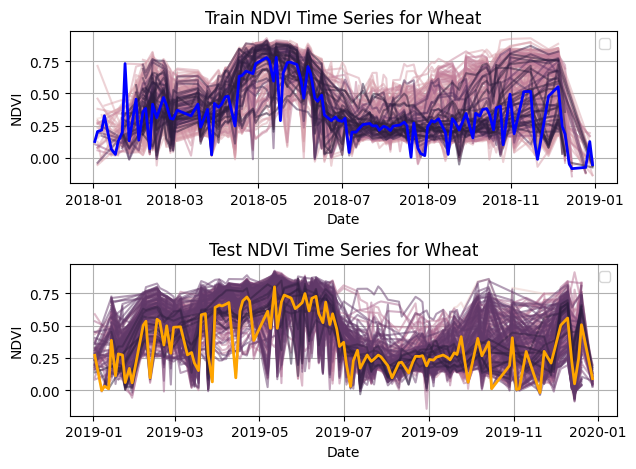

In [54]:
train_ndvi_crop = train_spectral_indices[train_spectral_indices['Crop type'] == 'wheat'][['Date', 'NDVI']]
test_ndvi_crop = test_spectral_indices[test_spectral_indices['Crop type'] == 'wheat'].set_index('PARCEL_ID')[['Date', 'NDVI']]
avg_train_ndvi_crop = train_avg_ndvi_time_series[train_avg_ndvi_time_series['Crop type'] == 'wheat']
avg_test_ndvi_crop = test_avg_ndvi_time_series[test_avg_ndvi_time_series['Crop type'] == 'wheat']

fig, axs = plt.subplots(2, 1)
sns.lineplot(data=train_ndvi_crop, x='Date', y='NDVI', hue=train_ndvi_crop.index, errorbar='sd', ax=axs[0], legend=False, color='blue', alpha=0.5)
axs[0].plot(avg_train_ndvi_crop['Date'], avg_train_ndvi_crop['NDVI'], color='blue', linewidth=2)
axs[0].set_title('Train NDVI Time Series for Wheat')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('NDVI')
axs[0].legend()
axs[0].grid(True)
sns.lineplot(data=test_ndvi_crop, x='Date', y='NDVI', hue=test_ndvi_crop.index, ax=axs[1], legend=False, color='orange', alpha=0.5)
axs[1].plot(avg_test_ndvi_crop['Date'], avg_test_ndvi_crop['NDVI'], color='orange', linewidth=2)
axs[1].set_title('Test NDVI Time Series for Wheat')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('NDVI')
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

In [66]:
# find the most similar peaks and their corresponding dates 
def correlate_train_test_series(avg_train_ndvi_crop, avg_test_ndvi_crop, crop_type, WINDOW_SIZE_DAYS = 15):
    ts1 = avg_train_ndvi_crop[['Date', 'NDVI']].rename(columns={'NDVI': 'NDVI_2018'}).set_index('Date')
    ts2 = avg_test_ndvi_crop[['Date', 'NDVI']].rename(columns={'NDVI': 'NDVI_2019'}).set_index('Date')

    ts1['day_of_year'] = ts1.index.dayofyear
    ts2['day_of_year'] = ts2.index.dayofyear

    aligned_df = pd.merge(
        ts1.reset_index(drop=True), 
        ts2.reset_index(drop=True), 
        on='day_of_year',
        how='inner' # Use 'inner' to handle leap years gracefully
    )

    rolling_corr = aligned_df['NDVI_2018'].rolling(window=WINDOW_SIZE_DAYS).corr(aligned_df['NDVI_2019'])
    aligned_df['correlation'] = rolling_corr

    max_corr_period = aligned_df.loc[aligned_df['correlation'].idxmax()]
    max_corr_value = max_corr_period['correlation']
    max_corr_day = int(max_corr_period['day_of_year'])
        
    print(f"Sliding Window Correlation Analysis for {crop_type} (Window Size: {WINDOW_SIZE_DAYS} days)")
    print("-" * 60)
    print(f"The highest correlation found is: {max_corr_value:.4f}")
    # The peak correlation is for the window *ending* on this day
    start_day = max_corr_day - WINDOW_SIZE_DAYS + 1
    print(f"This corresponds to the window of days from ~{start_day} to {max_corr_day} of the year.")

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
        
    # Plot 1: The two aligned time series
    ax1.plot(aligned_df['day_of_year'], aligned_df['NDVI_2018'], label='NDVI 2018 (Train)', color='blue', alpha=0.8)
    ax1.plot(aligned_df['day_of_year'], aligned_df['NDVI_2019'], label='NDVI 2019 (Test)', color='orange', alpha=0.8)
    ax1.axvline(x=max_corr_day, color='r', linestyle='--', label=f'Max Correlation at Day {max_corr_day}')
    ax1.axvline(x=start_day, color='r', linestyle='--')
    ax1.set_title('Aligned NDVI Time Series by Day of Year - ' + crop_type)
    ax1.set_ylabel('NDVI')
    ax1.legend()
    ax1.grid(True)
        
    # Plot 2: The sliding window correlation
    ax2.plot(aligned_df['day_of_year'], aligned_df['correlation'], color='green', label='Sliding Window Correlation')
    ax2.axvline(x=max_corr_day, color='r', linestyle='--', label=f'Max Correlation at Day {max_corr_day}')
    ax2.axvline(x=start_day, color='r', linestyle='--')
    ax2.set_title(f'{WINDOW_SIZE_DAYS}-Day Sliding Window Correlation')
    ax2.set_xlabel('Day of Year')
    ax2.set_ylabel('Pearson Correlation')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

Sliding Window Correlation Analysis for barley (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.8304
This corresponds to the window of days from ~168 to 182 of the year.


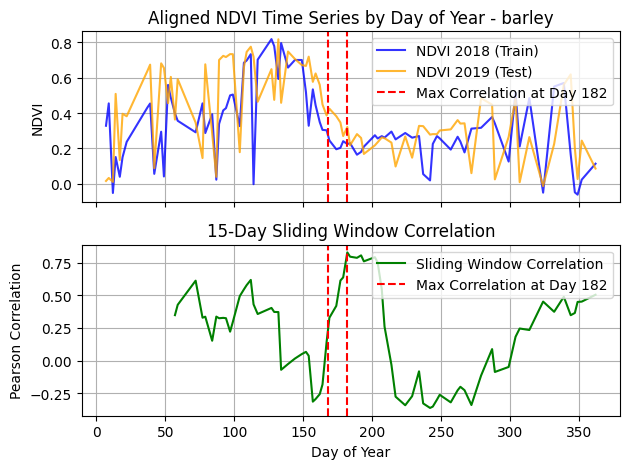

Sliding Window Correlation Analysis for corn (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.6019
This corresponds to the window of days from ~153 to 167 of the year.


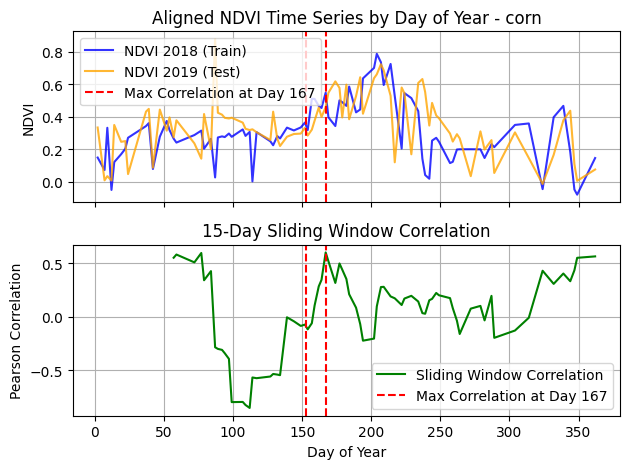

Sliding Window Correlation Analysis for forage crops (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.4521
This corresponds to the window of days from ~58 to 72 of the year.


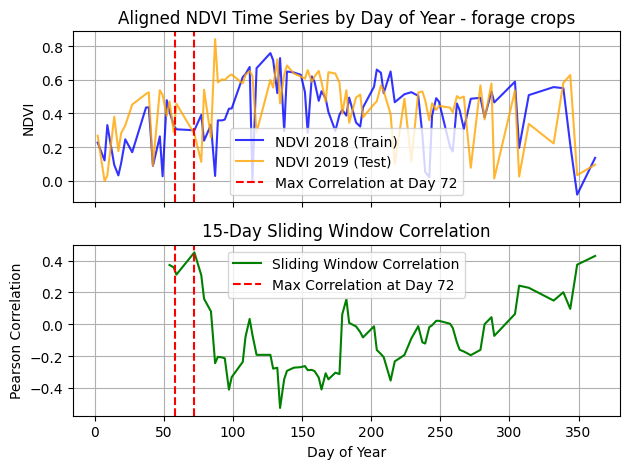

Sliding Window Correlation Analysis for meadows (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.7465
This corresponds to the window of days from ~58 to 72 of the year.


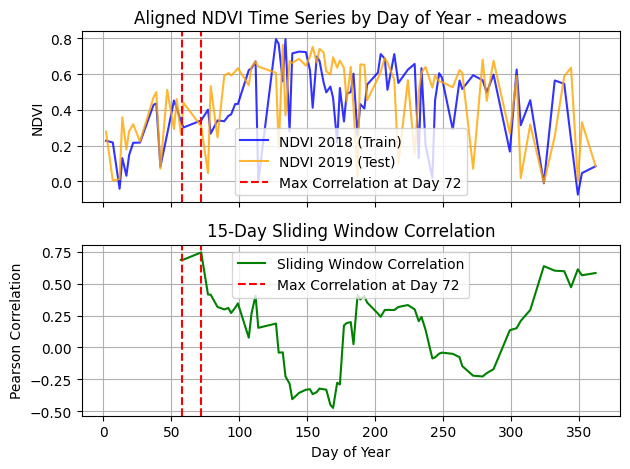

Sliding Window Correlation Analysis for oats (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.9073
This corresponds to the window of days from ~138 to 152 of the year.


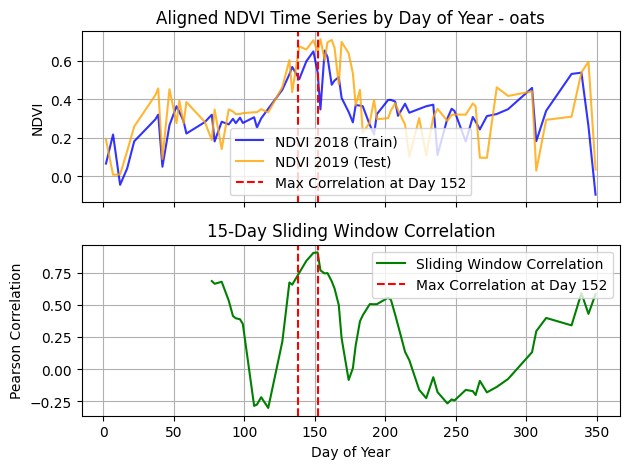

Sliding Window Correlation Analysis for oil seeds (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.6810
This corresponds to the window of days from ~178 to 192 of the year.


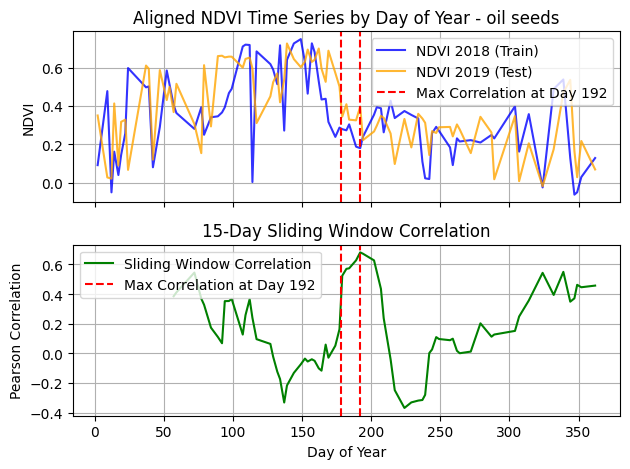

Sliding Window Correlation Analysis for root crops (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.8530
This corresponds to the window of days from ~145 to 159 of the year.


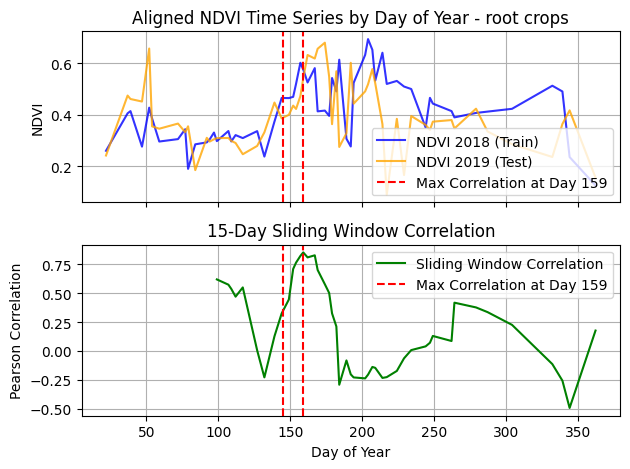

Sliding Window Correlation Analysis for rye (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.7156
This corresponds to the window of days from ~168 to 182 of the year.


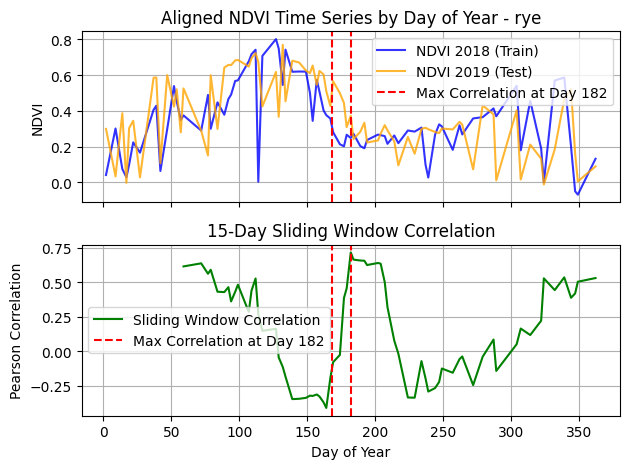

Sliding Window Correlation Analysis for wheat (Window Size: 15 days)
------------------------------------------------------------
The highest correlation found is: 0.8103
This corresponds to the window of days from ~188 to 202 of the year.


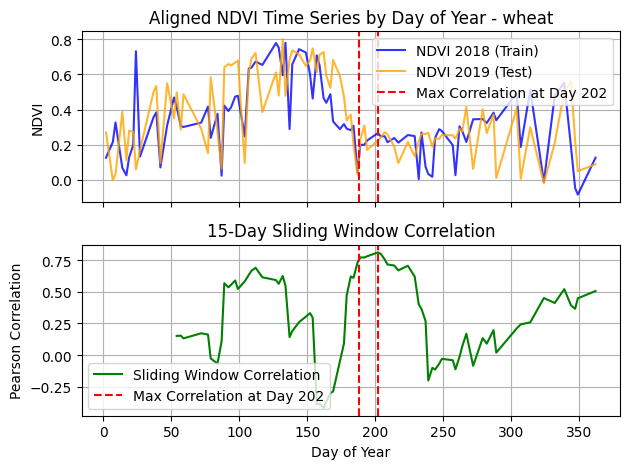

In [67]:
for crop_type in train_avg_ndvi_time_series['Crop type'].unique():
    avg_train_ndvi_crop = train_avg_ndvi_time_series[train_avg_ndvi_time_series['Crop type'] == crop_type]
    avg_test_ndvi_crop = test_avg_ndvi_time_series[test_avg_ndvi_time_series['Crop type'] == crop_type]
    correlate_train_test_series(avg_train_ndvi_crop, avg_test_ndvi_crop, crop_type)
    

In [ ]:
# remove the year from date stamps
# train_avg_ndvi_time_series['Date'] = 
# test_avg_ndvi_time_series['Date'] = 
print(train_avg_ndvi_time_series)

     Crop type   Date      NDVI
0       barley  01-04  0.236741
1       barley  01-07  0.327917
2       barley  01-09  0.454637
3       barley  01-12 -0.052963
4       barley  01-14  0.150648
...        ...    ...       ...
998      wheat  12-13 -0.045210
999      wheat  12-15 -0.083632
1000     wheat  12-25 -0.073785
1001     wheat  12-28  0.126502
1002     wheat  12-30 -0.051858

[1003 rows x 3 columns]
